In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Set clean visualization style
sns.set_style("whitegrid")

In [4]:
# Load dataset
df = pd.read_csv('E:\smart-logistics\Delivery_Logistics.csv')

# Drop unique identifier column if present
if 'delivery_id' in df.columns:
    df = df.drop(columns=['delivery_id'])

print("Initial Data Shape:", df.shape)
df.head()

Initial Data Shape: (25000, 14)


,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [6]:
# Fix timestamp strings by taking the numeric part after the dot
df['delivery_time_hours'] = pd.to_numeric(df['delivery_time_hours'].astype(str).str.split('.').str[-1], errors='coerce')
df['expected_time_hours'] = pd.to_numeric(df['expected_time_hours'].astype(str).str.split('.').str[-1], errors='coerce')

# Fill missing numerical values with column mean
df = df.fillna(df.mean(numeric_only=True))

# Fill missing text values with column mode
df = df.fillna(df.mode().iloc[0])

# Calculate delivery cost per kilometer
df['cost_per_km'] = df['delivery_cost'] / df['distance_km']

print("Cleaned Data Shape:", df.shape)
df.info()

Cleaned Data Shape: (25000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_partner     25000 non-null  str    
 1   package_type         25000 non-null  str    
 2   vehicle_type         25000 non-null  str    
 3   delivery_mode        25000 non-null  str    
 4   region               25000 non-null  str    
 5   weather_condition    25000 non-null  str    
 6   distance_km          25000 non-null  float64
 7   package_weight_kg    25000 non-null  float64
 8   delivery_time_hours  25000 non-null  int64  
 9   expected_time_hours  25000 non-null  int64  
 10  delayed              25000 non-null  str    
 11  delivery_status      25000 non-null  str    
 12  delivery_rating      25000 non-null  int64  
 13  delivery_cost        25000 non-null  float64
 14  cost_per_km          25000 non-null  float64
dtypes: float64(4), 

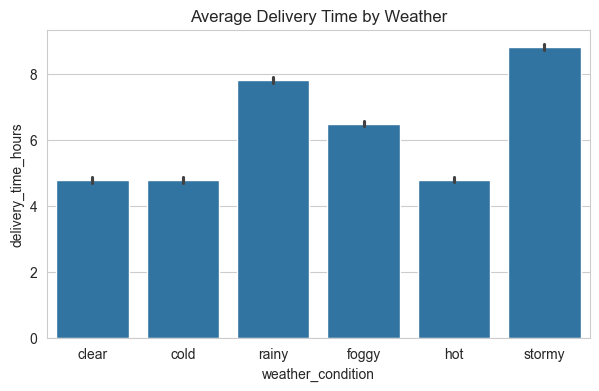

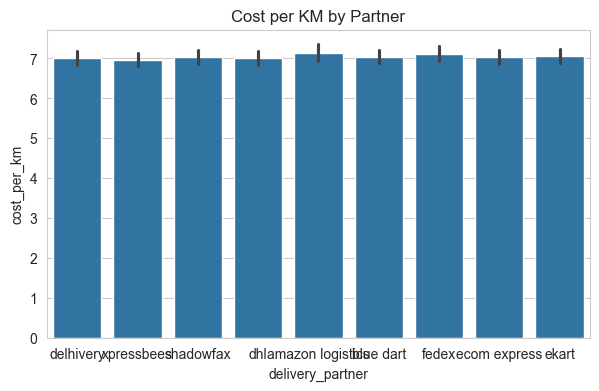

In [7]:
# Chart 1: Average delivery time across weather conditions
plt.figure(figsize=(7, 4))
sns.barplot(x='weather_condition', y='delivery_time_hours', data=df)
plt.title('Average Delivery Time by Weather')
plt.show()

# Chart 2: Cost efficiency across delivery partners
plt.figure(figsize=(7, 4))
sns.barplot(x='delivery_partner', y='cost_per_km', data=df)
plt.title('Cost per KM by Partner')
plt.show()

In [8]:
# Prepare features and target
drop_cols = ['delivery_time_hours', 'delayed', 'delivery_status', 'delivery_rating']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['delivery_time_hours']

# One-hot encode categorical features simply
X = pd.get_dummies(X, drop_first=True)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train basic Random Forest model
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [9]:
# Evaluate model
predictions = model.predict(X_test)

print("--- Model Results ---")
print("Mean Absolute Error (hours):", round(mean_absolute_error(y_test, predictions), 2))
print("R2 Score:", round(r2_score(y_test, predictions), 2))

# Quick sample test
actual_time = y_test.iloc[0]
predicted_time = predictions[0]

print(f"\nSample Prediction - Actual: {actual_time} hrs | Predicted: {predicted_time:.2f} hrs")

--- Model Results ---
Mean Absolute Error (hours): 1.34
R2 Score: 0.7

Sample Prediction - Actual: 7 hrs | Predicted: 8.74 hrs
